# 4. Similarity Search with Cosine Similarity and FAISS

This notebook builds the visual similarity-search system using the
2048-dimensional ResNet-50 embeddings generated in Notebook 3.

### Objectives

- Load the complete product embedding matrix
- Validate the embedding-to-product mapping
- Understand and implement cosine similarity
- L2-normalize the embeddings
- Build a brute-force similarity-search baseline
- Retrieve the Top-K visually similar products
- Build an exact FAISS similarity-search index
- Compare FAISS results with the brute-force implementation
- Save and reload the FAISS index

### Retrieval Pipeline

Query image
→ ResNet-50 embedding
→ L2 normalization
→ FAISS similarity search
→ Top-K results
→ Product ID mapping
→ Product metadata

## 1- Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

import faiss

## 2- Project Paths

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EMBEDDINGS_DIR = PROJECT_ROOT / "embeddings"
MODEL_DIR = PROJECT_ROOT / "models"

METADATA_PATH = PROCESSED_DIR / "product_metadata.csv"

EMBEDDINGS_PATH = EMBEDDINGS_DIR / "product_embeddings.npy"
EMBEDDING_IDS_PATH = EMBEDDINGS_DIR / "embedding_product_ids.npy"

MODEL_PATH = MODEL_DIR / "resnet50_feature_extractor.pth"

FAISS_INDEX_PATH = EMBEDDINGS_DIR / "product_embeddings_faiss.index"

print("Metadata:", METADATA_PATH)
print("Embeddings:", EMBEDDINGS_PATH)
print("Embedding IDs:", EMBEDDING_IDS_PATH)
print("Model:", MODEL_PATH)
print("FAISS index:", FAISS_INDEX_PATH)

Metadata: d:\Projects\VisualProductSearch\data\processed\product_metadata.csv
Embeddings: d:\Projects\VisualProductSearch\embeddings\product_embeddings.npy
Embedding IDs: d:\Projects\VisualProductSearch\embeddings\embedding_product_ids.npy
Model: d:\Projects\VisualProductSearch\models\resnet50_feature_extractor.pth
FAISS index: d:\Projects\VisualProductSearch\embeddings\product_embeddings_faiss.index


In [3]:
print("Metadata exists:", METADATA_PATH.exists())
print("Embeddings exist:", EMBEDDINGS_PATH.exists())
print("Embedding IDs exist:", EMBEDDING_IDS_PATH.exists())
print("Model exists:", MODEL_PATH.exists())

Metadata exists: True
Embeddings exist: True
Embedding IDs exist: True
Model exists: True


## 3- Load Product Embeddings

The embeddings generated in Notebook 3 represent the complete product
catalog.

Each product is represented by a 2048-dimensional ResNet-50 feature
vector.

In [4]:
embeddings = np.load(EMBEDDINGS_PATH)

print("Embeddings shape:", embeddings.shape)
print("Embeddings dtype:", embeddings.dtype)

Embeddings shape: (44441, 2048)
Embeddings dtype: float32


## 4- Load Product IDs

In [5]:
product_ids = np.load(EMBEDDING_IDS_PATH)

print("Product IDs shape:", product_ids.shape)
print("First 10 product IDs:", product_ids[:10])

Product IDs shape: (44441,)
First 10 product IDs: [15970 39386 59263 21379 53759  1855 30805 26960 29114 30039]


## 5- Load Product Metadata

In [6]:
metadata_df = pd.read_csv(METADATA_PATH)

print("Metadata shape:", metadata_df.shape)
print(metadata_df.head())

Metadata shape: (44441, 11)
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  \
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt   
1  2012.0  Casual             Peter England Men Party Blue Jeans   
2  2016.0  Casual                       Titan Women Silver Watch   
3  2011.0  Casual  Manchester United Men Solid Black Track Pants   
4  2012.0  Casual                          Puma Men Grey T-shirt   

                                          image_path  
0  d:\Projects\VisualProductSearch\data

## 6- Validate Embedding and Product Mapping

The row position of an embedding must correspond to the correct
product ID.

This mapping is critical because FAISS returns vector indices rather
than the original product IDs.

In [7]:
assert embeddings.shape[0] == len(product_ids)
assert embeddings.shape[0] == len(metadata_df)

assert len(np.unique(product_ids)) == len(product_ids)

assert np.array_equal(
    product_ids,
    metadata_df["id"].to_numpy()
)

print("✓ Number of embeddings:", len(embeddings))
print("✓ Number of product IDs:", len(product_ids))
print("✓ Number of metadata records:", len(metadata_df))
print("✓ Product IDs are unique")
print("✓ Embedding-to-metadata alignment verified")

✓ Number of embeddings: 44441
✓ Number of product IDs: 44441
✓ Number of metadata records: 44441
✓ Product IDs are unique
✓ Embedding-to-metadata alignment verified


## 7- Inspect Embeddings

In [8]:
print("Minimum:", embeddings.min())
print("Maximum:", embeddings.max())
print("Mean:", embeddings.mean())
print("Standard deviation:", embeddings.std())

print("Contains NaN:", np.isnan(embeddings).any())
print("Contains Inf:", np.isinf(embeddings).any())

Minimum: 0.0
Maximum: 10.601868
Mean: 0.06266266
Standard deviation: 0.24635334
Contains NaN: False
Contains Inf: False


## 8- L2 Normalization

Cosine similarity compares the direction of two vectors.

For FAISS, we will use an Inner Product index. When both the catalog
embeddings and query embedding are L2-normalized, their inner product
is equivalent to cosine similarity.

Therefore:

L2-normalized embeddings + Inner Product
= Cosine Similarity

In [9]:
normalized_embeddings = embeddings.copy()

faiss.normalize_L2(normalized_embeddings)

print("Normalized embeddings shape:", normalized_embeddings.shape)

Normalized embeddings shape: (44441, 2048)


In [10]:
norms = np.linalg.norm(normalized_embeddings, axis=1)

print("Minimum norm:", norms.min())
print("Maximum norm:", norms.max())
print("Mean norm:", norms.mean())

Minimum norm: 0.99999976
Maximum norm: 1.0000002
Mean norm: 1.0


## 9- Brute-Force Cosine Similarity Search

The brute-force approach compares the query embedding against every
product embedding in the catalog.

Because the embeddings are already L2-normalized, the dot product
between the query and catalog embeddings is equivalent to cosine
similarity.

This provides an exact baseline that can later be compared with FAISS.

In [11]:
def brute_force_search(query_embedding, catalog_embeddings, top_k=5):
    query_embedding = query_embedding.astype("float32").reshape(1, -1)

    # Normalize query embedding
    query_embedding = query_embedding.copy()
    faiss.normalize_L2(query_embedding)

    # Cosine similarity = dot product after normalization
    similarities = catalog_embeddings @ query_embedding.T
    similarities = similarities.ravel()

    top_indices = np.argsort(-similarities)[:top_k]
    top_scores = similarities[top_indices]

    return top_indices, top_scores

## 10- Load ResNet-50 for Query Images

In [12]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 2050


In [13]:
resnet50 = models.resnet50(weights=None)
resnet50.fc = nn.Identity()

resnet50.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=True
    )
)

resnet50 = resnet50.to(device)
resnet50.eval()

for parameter in resnet50.parameters():
    parameter.requires_grad = False

print("ResNet-50 feature extractor loaded.")

ResNet-50 feature extractor loaded.


## 11- Define Query Image Preprocessing

In [14]:
image_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 12- Query Image → Embedding

A query image must go through exactly the same preprocessing and
ResNet-50 feature-extraction pipeline used to generate the catalog
embeddings.

This ensures that the query and catalog vectors exist in the same
feature space.

In [15]:
def generate_query_embedding(image_path):
    image = Image.open(image_path).convert("RGB")

    tensor = image_transform(image)
    tensor = tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        features = resnet50(tensor)

    features = features.cpu().numpy().astype("float32")

    return features

## 13- Select a Catalog Image as Query

In [16]:
query_index = 0

query_product_id = int(product_ids[query_index])
query_image_path = Path(
    metadata_df.iloc[query_index]["image_path"]
)

print("Query product ID:", query_product_id)
print("Query image:", query_image_path)

Query product ID: 15970
Query image: d:\Projects\VisualProductSearch\data\fashion-product-images-small\images\15970.jpg


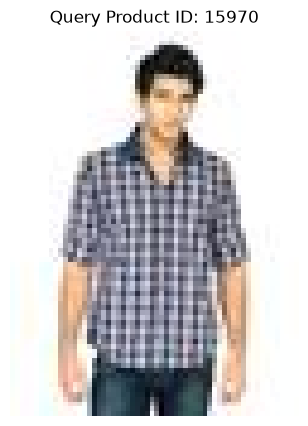

In [17]:
query_image = Image.open(query_image_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(query_image)
plt.axis("off")
plt.title(f"Query Product ID: {query_product_id}")
plt.show()

## 14- Generate Query Embedding

In [18]:
query_embedding = generate_query_embedding(query_image_path)

print("Query embedding shape:", query_embedding.shape)
print("Query embedding dtype:", query_embedding.dtype)

Query embedding shape: (1, 2048)
Query embedding dtype: float32


## 15- Brute-Force Search

In [19]:
top_k = 5

brute_indices, brute_scores = brute_force_search(
    query_embedding,
    normalized_embeddings,
    top_k=top_k
)

print("Retrieved indices:", brute_indices)
print("Similarity scores:", brute_scores)

Retrieved indices: [    0  3899 23699 27446 35219]
Similarity scores: [0.9999992  0.947692   0.94705814 0.94705814 0.9456637 ]


## 16- Convert Search Results into Products

In [20]:
def build_results(indices, scores, metadata_df, product_ids):
    results = metadata_df.iloc[indices].copy()

    results["similarity"] = scores
    results["product_id"] = product_ids[indices]

    return results[
        [
            "product_id",
            "productDisplayName",
            "articleType",
            "baseColour",
            "gender",
            "image_path",
            "similarity"
        ]
    ].reset_index(drop=True)

In [21]:
brute_results = build_results(
    brute_indices,
    brute_scores,
    metadata_df,
    product_ids
)

brute_results

,product_id,productDisplayName,articleType,baseColour,gender,image_path,similarity
0,15970,Turtle Check Men Navy Blue Shirt,Shirts,Navy Blue,Men,d:\Projects\VisualProductSearch\data\fashion-p...,0.999999
1,15971,Turtle Check Men Green Shirt,Shirts,Green,Men,d:\Projects\VisualProductSearch\data\fashion-p...,0.947692
2,8584,Scullers Men Scul Purple Shirts,Shirts,Purple,Men,d:\Projects\VisualProductSearch\data\fashion-p...,0.947058
3,8585,Scullers Men Scul Purple Shirts,Shirts,Purple,Men,d:\Projects\VisualProductSearch\data\fashion-p...,0.947058
4,9733,Indian Terrain Men Chase Green Shirts,Shirts,Green,Men,d:\Projects\VisualProductSearch\data\fashion-p...,0.945664


## 17- Visually Display the Retrieved Products

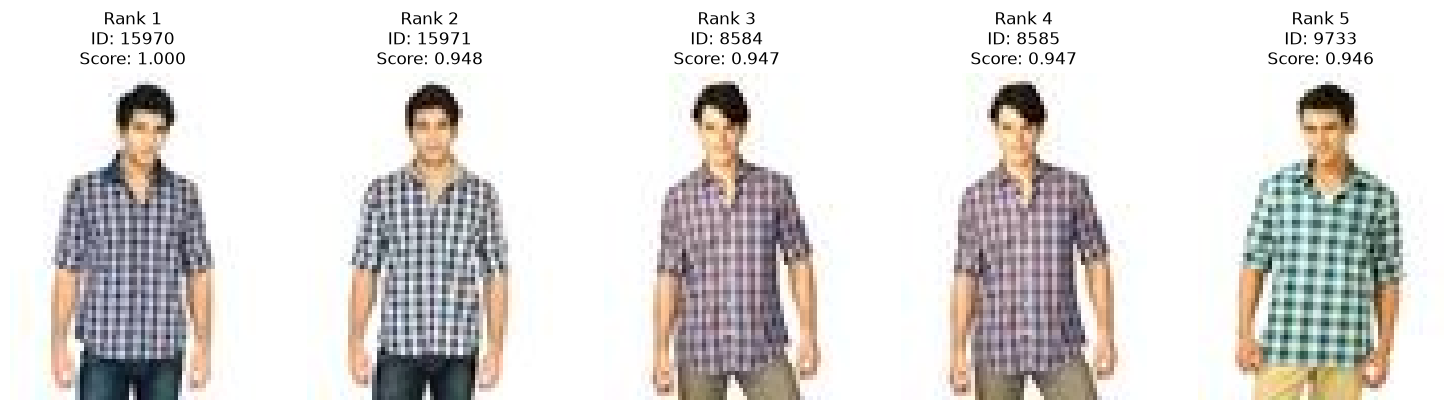

In [22]:
fig, axes = plt.subplots(1, top_k, figsize=(15, 4))

for rank, (index, score) in enumerate(
    zip(brute_indices, brute_scores),
    start=1
):
    image_path = metadata_df.iloc[index]["image_path"]
    image = Image.open(image_path).convert("RGB")

    axes[rank - 1].imshow(image)
    axes[rank - 1].axis("off")

    axes[rank - 1].set_title(
        f"Rank {rank}\n"
        f"ID: {product_ids[index]}\n"
        f"Score: {score:.3f}"
    )

plt.tight_layout()
plt.show()

## 18- FAISS Similarity Search

FAISS provides optimized data structures and search operations for
vector similarity search.

We use `IndexFlatIP` because:

- `Flat` means the vectors are stored directly without compression.
- `IP` means Inner Product.
- The search is exact.

Because our vectors are L2-normalized, Inner Product corresponds to
cosine similarity.

In [23]:
embedding_dimension = normalized_embeddings.shape[1]

index = faiss.IndexFlatIP(embedding_dimension)

print("Embedding dimension:", embedding_dimension)
print("FAISS index created.")
print("Index contains:", index.ntotal, "vectors")

Embedding dimension: 2048
FAISS index created.
Index contains: 0 vectors


## 19- Add Catalog Embeddings

In [24]:
index.add(normalized_embeddings)

print("FAISS index contains:", index.ntotal, "vectors")

FAISS index contains: 44441 vectors


## 20- Search Using FAISS

In [25]:
normalized_query = query_embedding.copy()

faiss.normalize_L2(normalized_query)

print("Normalized query shape:", normalized_query.shape)

Normalized query shape: (1, 2048)


In [26]:
faiss_scores, faiss_indices = index.search(
    normalized_query,
    top_k
)

print("FAISS indices:", faiss_indices[0])
print("FAISS scores:", faiss_scores[0])

FAISS indices: [    0  3899 27446 23699 35219]
FAISS scores: [0.9999992  0.947692   0.9470581  0.9470581  0.94566363]


## 21- Convert FAISS Results into Products

In [27]:
faiss_indices = faiss_indices[0]
faiss_scores = faiss_scores[0]

faiss_results = build_results(
    faiss_indices,
    faiss_scores,
    metadata_df,
    product_ids
)

faiss_results

,product_id,productDisplayName,articleType,baseColour,gender,image_path,similarity
0,15970,Turtle Check Men Navy Blue Shirt,Shirts,Navy Blue,Men,d:\Projects\VisualProductSearch\data\fashion-p...,0.999999
1,15971,Turtle Check Men Green Shirt,Shirts,Green,Men,d:\Projects\VisualProductSearch\data\fashion-p...,0.947692
2,8585,Scullers Men Scul Purple Shirts,Shirts,Purple,Men,d:\Projects\VisualProductSearch\data\fashion-p...,0.947058
3,8584,Scullers Men Scul Purple Shirts,Shirts,Purple,Men,d:\Projects\VisualProductSearch\data\fashion-p...,0.947058
4,9733,Indian Terrain Men Chase Green Shirts,Shirts,Green,Men,d:\Projects\VisualProductSearch\data\fashion-p...,0.945664


## 22- Brute-Force vs FAISS Verification

Both methods should produce the same results because `IndexFlatIP`
performs exact inner-product search.

Since both the catalog and query embeddings are L2-normalized,
inner-product ranking is equivalent to cosine-similarity ranking.

Therefore, the retrieved indices and similarity scores should match
the brute-force implementation up to small floating-point differences.

In [28]:
print("Brute-force indices:")
print(brute_indices)

print("\nFAISS indices:")
print(faiss_indices)

Brute-force indices:
[    0  3899 23699 27446 35219]

FAISS indices:
[    0  3899 27446 23699 35219]


In [29]:
brute_pairs = list(zip(brute_indices, brute_scores))
faiss_pairs = list(zip(faiss_indices, faiss_scores))

print("Brute-force results:")
for idx, score in brute_pairs:
    print(f"Index: {idx:5d} | Score: {score:.8f}")

print("\nFAISS results:")
for idx, score in faiss_pairs:
    print(f"Index: {idx:5d} | Score: {score:.8f}")

Brute-force results:
Index:     0 | Score: 0.99999923
Index:  3899 | Score: 0.94769198
Index: 23699 | Score: 0.94705814
Index: 27446 | Score: 0.94705814
Index: 35219 | Score: 0.94566369

FAISS results:
Index:     0 | Score: 0.99999923
Index:  3899 | Score: 0.94769198
Index: 27446 | Score: 0.94705808
Index: 23699 | Score: 0.94705808
Index: 35219 | Score: 0.94566363


In [30]:
assert np.allclose(
    np.sort(brute_scores),
    np.sort(faiss_scores),
    atol=1e-5
)

assert set(brute_indices) == set(faiss_indices)

print("✓ Brute-force and FAISS retrieved the same Top-K products")
print("✓ Similarity scores match within floating-point tolerance")

✓ Brute-force and FAISS retrieved the same Top-K products
✓ Similarity scores match within floating-point tolerance


## 23- Test Multiple Query Images

In [31]:
test_indices = [0, 100, 1000, 5000, 10000]

for query_index in test_indices:
    query_product_id = int(product_ids[query_index])
    query_path = Path(
        metadata_df.iloc[query_index]["image_path"]
    )

    query_embedding = generate_query_embedding(query_path)

    normalized_query = query_embedding.copy()
    faiss.normalize_L2(normalized_query)

    scores, indices = index.search(
        normalized_query,
        top_k
    )

    print(
        f"Query ID: {query_product_id} | "
        f"Top result ID: {product_ids[indices[0][0]]} | "
        f"Score: {scores[0][0]:.4f}"
    )

Query ID: 15970 | Top result ID: 15970 | Score: 1.0000
Query ID: 28456 | Top result ID: 28456 | Score: 1.0000
Query ID: 12367 | Top result ID: 12367 | Score: 1.0000
Query ID: 39927 | Top result ID: 39927 | Score: 1.0000
Query ID: 37956 | Top result ID: 37956 | Score: 1.0000


## 24- Save FAISS Index

The FAISS index is saved so that the application does not need to
rebuild the catalog index every time the backend starts.

In [32]:
faiss.write_index(
    index,
    str(FAISS_INDEX_PATH)
)

print("FAISS index saved to:")
print(FAISS_INDEX_PATH)

FAISS index saved to:
d:\Projects\VisualProductSearch\embeddings\product_embeddings_faiss.index


In [33]:
loaded_index = faiss.read_index(
    str(FAISS_INDEX_PATH)
)

print("Reloaded index contains:",
      loaded_index.ntotal,
      "vectors")

Reloaded index contains: 44441 vectors


In [34]:
reload_scores, reload_indices = loaded_index.search(
    normalized_query,
    top_k
)

print("Reloaded index results:")
print(reload_indices[0])
print(reload_scores[0])

Reloaded index results:
[10000  8187 38909 39436 42119]
[0.9999988  0.98397124 0.96817565 0.96203184 0.9515561 ]


# 25- Notebook Summary

This notebook implemented the visual similarity-search system using the
ResNet-50 embeddings generated in Notebook 3.

### Similarity Search

- Catalog size: **44,441 products**
- Embedding dimension: **2,048**
- Similarity measure: **Cosine similarity**
- Embedding normalization: **L2 normalization**
- FAISS index: **IndexFlatIP**
- Search type: **Exact similarity search**
- Retrieval: **Top-K**

The catalog embeddings were L2-normalized so that inner-product search
could be used as an equivalent implementation of cosine similarity.

### Brute-Force Baseline

A brute-force cosine-similarity implementation was created first to
establish an exact baseline.

The query embedding was compared against all catalog embeddings and the
highest-scoring products were retrieved.

### FAISS Search

An exact FAISS `IndexFlatIP` index was created using the normalized
catalog embeddings.

The FAISS results were compared against the brute-force implementation.
The retrieved Top-K sets and similarity scores were verified to agree
within floating-point tolerance. Tied results may appear in a different
order because both methods can resolve equal scores differently.

### Validation

The following were verified:

- Correct embedding and metadata alignment
- Correct embedding dimension
- Correct number of indexed products
- Successful Top-K retrieval
- Brute-force and FAISS Top-K retrieval agreement
- Similarity scores agree within floating-point tolerance
- Tied results may have different ordering
- Saved FAISS index can be reloaded successfully
- Reloaded index produces the same search results

### Output

The FAISS index is saved as:

`embeddings/product_embeddings_faiss.index`

The catalog embeddings and product-ID mapping are stored as:

`embeddings/product_embeddings.npy`

`embeddings/embedding_product_ids.npy`

### Next Step

The retrieval pipeline is now functional.

In **Notebook 5**, the system will be evaluated quantitatively using
retrieval metrics such as Recall@K, Precision@K, and mAP, along with
qualitative inspection of retrieved results.